Processing Panel 0...


Processing Panel 1...


Processing Panel 2...


Processing Panel 3...


Processing Panel 4...


Processing Panel 5...


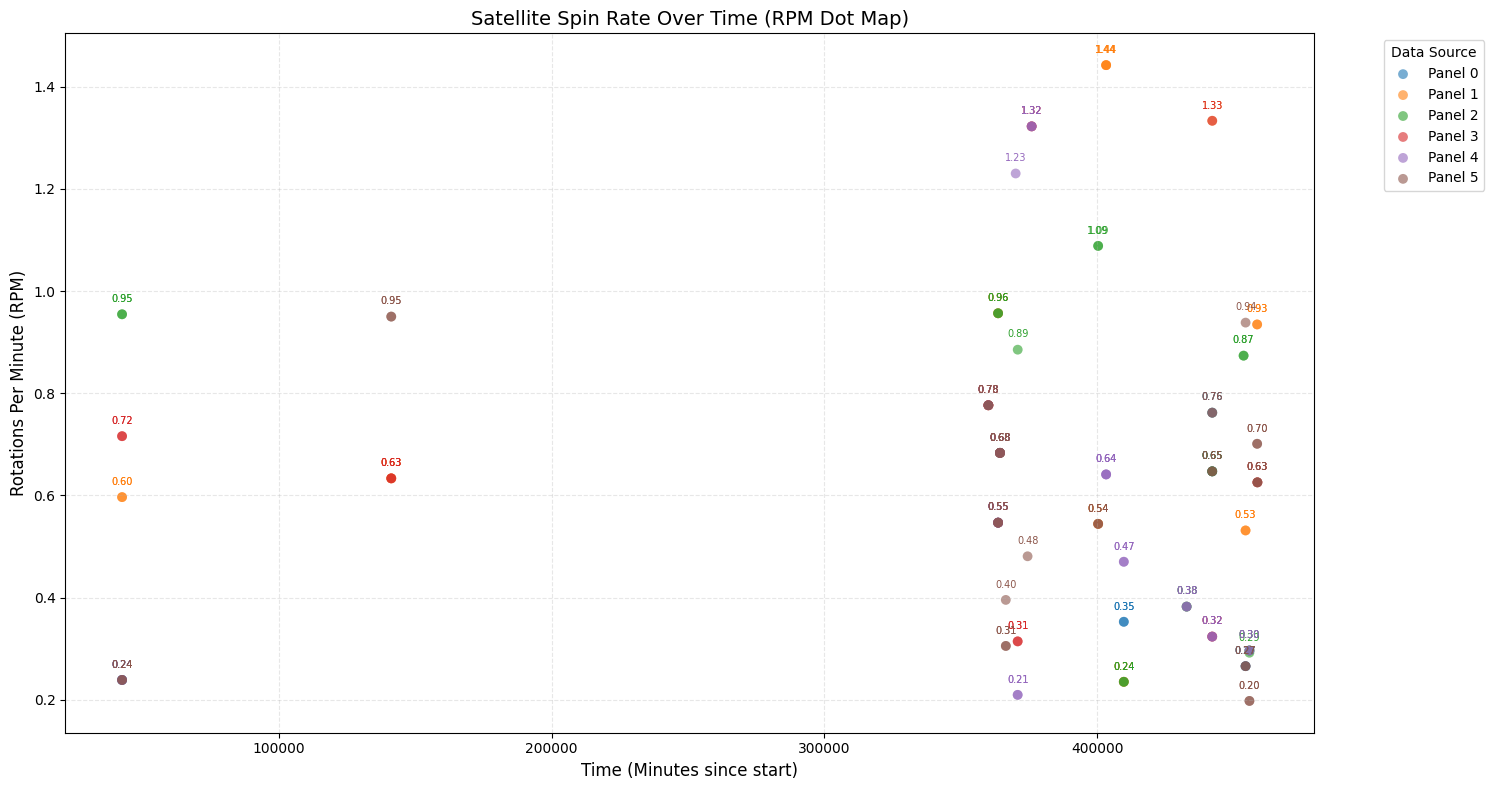

In [2]:
import ssl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

# Bypass SSL for data download
ssl._create_default_https_context = ssl._create_unverified_context

# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================
url = "https://docs.google.com/spreadsheets/d/1SNtKn_p-X0sz3TAKy0b2ndkeiHQwIktb/export?format=csv&gid=1692859273"

try:
    df = pd.read_csv(url)
    df.columns = df.columns.str.strip()
    df["Ground Time"] = pd.to_datetime(df["Ground Time"], format="mixed", dayfirst=True)
    df = df.sort_values("Ground Time")

    # Time in seconds and minutes
    start_time = df["Ground Time"].iloc[0]
    df["Seconds"] = (df["Ground Time"] - start_time).dt.total_seconds()
    df["Minutes"] = df["Seconds"] / 60

    panel_cols = [f"solar_panels{i}" for i in range(6)]
except Exception as e:
    print(f"Error loading data: {e}")
    exit()


# ============================================================
# 2. SLIDING WINDOW FFT FUNCTION
# ============================================================
def extract_rpm_over_time(df, panel_col, window_size_sec=1800, step_size_sec=600):
    """
    Chunks the data into smaller windows to find spikes.
    window_size_sec: 30 minutes (was 60, reduced to find more points)
    step_size_sec: 10 minutes (how often we take a measurement)
    """
    results = []
    max_time = df["Seconds"].max()

    for start in np.arange(0, max_time - window_size_sec, step_size_sec):
        end = start + window_size_sec
        window_df = df[(df["Seconds"] >= start) & (df["Seconds"] < end)]

        if len(window_df) < 20:
            continue

        signal = window_df[panel_col].to_numpy()
        t_seg = window_df["Seconds"].to_numpy()

        # FFT logic
        n = len(signal)
        dt = np.mean(np.diff(t_seg))
        # Remove mean (DC offset) and apply window to reduce leakage
        centered = signal - np.mean(signal)
        yf = np.abs(fft(centered))
        xf = fftfreq(n, dt)

        # Filter range: focusing on expected satellite spin rates
        mask = (xf > 0.0001) & (xf < 0.2)
        xf_f, yf_f = xf[mask], yf[mask]

        if len(yf_f) == 0:
            continue

        # RELAXED PROMINENCE: Look for peaks that are at least 5% of the max
        peaks, _ = find_peaks(yf_f, prominence=(np.max(yf_f) * 0.05) + 0.001)

        if len(peaks) > 0:
            # Take the highest peak found in this specific window
            best_peak_idx = peaks[np.argmax(yf_f[peaks])]
            rpm = xf_f[best_peak_idx] * 60
            amp = yf_f[best_peak_idx]

            results.append({
                "time_min": (start + (window_size_sec / 2)) / 60,
                "rpm": rpm,
                "amp": amp
            })

    return pd.DataFrame(results)


# ============================================================
# 3. PROCESS AND PLOT
# ============================================================
plt.figure(figsize=(15, 8))

# Fixed the deprecation warning by using the new colormap API
cmap = plt.get_cmap('tab10')

any_points = False

for i, col in enumerate(panel_cols):
    panel_name = f"Panel {i}"
    print(f"Processing {panel_name}...")

    panel_data = extract_rpm_over_time(df, col)

    if not panel_data.empty:
        any_points = True
        color = cmap(i)

        # Plot: X = Time, Y = RPM
        plt.scatter(
            panel_data["time_min"],
            panel_data["rpm"],
            s=50,  # Standardized size for clarity
            color=color,
            alpha=0.6,
            label=panel_name,
            edgecolors='none'
        )

        # Add labels on each dot
        for _, row in panel_data.iterrows():
            plt.text(
                row["time_min"],
                row["rpm"] + 0.02,  # Slightly above the dot
                f"{row['rpm']:.2f}",
                fontsize=7,
                color=color,
                ha='center',
                va='bottom'
            )

if any_points:
    plt.title("Satellite Spin Rate Over Time (RPM Dot Map)", fontsize=14)
    plt.xlabel("Time (Minutes since start)", fontsize=12)
    plt.ylabel("Rotations Per Minute (RPM)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend(title="Data Source", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("\n[!] No peaks detected. Suggestions:")
    print("1. Decrease 'prominence' in find_peaks.")
    print("2. Check if the signal in the spreadsheet has actual oscillations.")
    print("3. Try a smaller 'window_size_sec'.")